Dataset Preview:
   Glucose   BMI  Age  BloodPressure  Insulin  Outcome
0      182  21.1   45             99      100        1
1      131  35.6   67             92      199        1
2      172  19.6   68             68      234        1
3       94  39.7   21            102       83        0
4      186  35.0   20            113       61        1

Columns:
Index(['Glucose', 'BMI', 'Age', 'BloodPressure', 'Insulin', 'Outcome'], dtype='object')

Decision Tree Accuracy: 1.0
Bagging Accuracy: 1.0


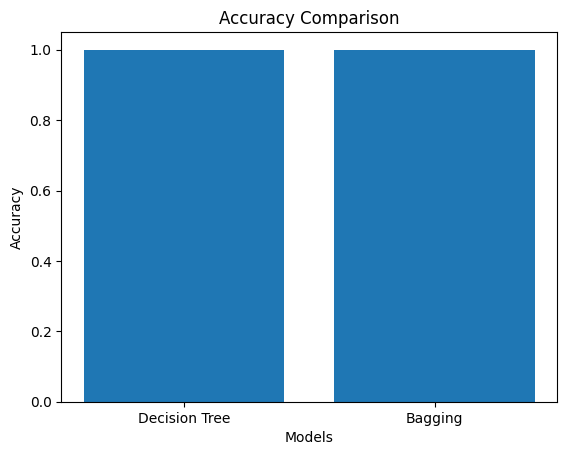

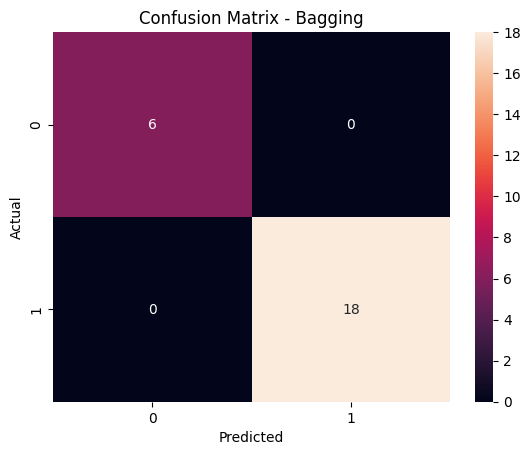

In [ ]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# ================================
# 2. LOAD YOUR DATASET
# ================================
df = pd.read_csv('diabetes_bagging.csv')

print("Dataset Preview:")
print(df.head())

print("\nColumns:")
print(df.columns)

# ================================
# 3. DEFINE FEATURES & TARGET
# ================================
# Make sure target column is 'Outcome'
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# ================================
# 4. TRAIN-TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# ================================
# 5. DECISION TREE MODEL
# ================================
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
dt_acc = accuracy_score(y_test, y_pred_dt)

print("\nDecision Tree Accuracy:", dt_acc)

# ================================
# 6. BAGGING CLASSIFIER
# ================================
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)

bag.fit(X_train, y_train)

y_pred_bag = bag.predict(X_test)
bag_acc = accuracy_score(y_test, y_pred_bag)

print("Bagging Accuracy:", bag_acc)

# ================================
# 7. ACCURACY COMPARISON GRAPH
# ================================
models = ['Decision Tree', 'Bagging']
accuracies = [dt_acc, bag_acc]

plt.figure()
plt.bar(models, accuracies)
plt.title('Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.show()

# ================================
# 8. CONFUSION MATRIX (Bagging)
# ================================
cm = confusion_matrix(y_test, y_pred_bag)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix - Bagging')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()